In [41]:
from dotenv import load_dotenv
load_dotenv()
from typing_extensions import TypedDict,Annotated
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langchain_core.tools import tool

from langgraph.prebuilt import ToolNode,tools_condition

In [42]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [43]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",  
)

In [44]:
class State(TypedDict):
    messages : Annotated[list,add_messages]
    

In [45]:
@tool
def get_stock_price(symbol: str) -> dict:
    """Return stock price for a given symbol."""
    price = {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0,
        "RIL": 87.6
    }.get(symbol, 0.0)

    return {"symbol": symbol, "price": price}

tools = [get_stock_price]
llm_with_tools = llm.bind_tools(tools)

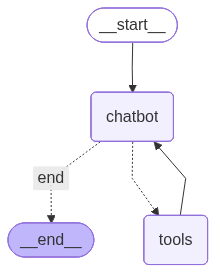

In [46]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node(chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    {
        "tools": "tools",
        "end": END
    }
)
builder.add_edge("tools","chatbot")

graph = builder.compile(checkpointer = memory)

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [48]:
config = { 'configurable': { 'thread_id': '1'} }

msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config)
print(state["messages"][-1].content)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 50.654344585s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [ ]:
state = graph.invoke({"messages": [{"role": "user", "content": "Who invented theory of relativity? print person name only"}]},config = config)
print(state["messages"][-1].content)

[{'type': 'text', 'text': 'Albert Einstein', 'extras': {'signature': 'CoICAb4+9vub1XPBUAMBCXz3aTG/esXyDMsgfwDq3C9+rFO8elnt/LSsHs6Ci2KCTZlCHJ3ZXOkPuUd0pzuYdNa8MWRgOkC/NU/1fZvBR3wIJiMeng1ZXGftiHHjwxM1EyqqFdgfUuGeCEqHkU0BvEsbZWNHPjVrgrjCdL3QSx4OjtQPyjioSr7FMwFfSlRy4kXVJcVIJojx/uXFWw23dDH6L6fVBbUoaF/VeZTWG8drqXnoYIF0Pq4d+OToBXtcV7e9uqQZXatEaIiW7dRQgPd50mXfkMDSFQCzLqb7UBgVai8F7Bah6oNQeHx8SePopIl5qSb/tryzfbsyvI/jarAjftZK'}}]


In [ ]:
msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]},config = config)
print(state["messages"][-1].content)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 43.928100387s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [ ]:
msg = "add the price of 10 RIL stock to the previous total cost"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]},config = config)
print(state["messages"][-1].content)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 32.15508477s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi